In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load dataset from CSV file
data = pd.read_csv('L-R-B data.csv')

C:\Users\ompat\AppData\Local\Temp\ipykernel_13332\1891273594.py:2: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('L-R-B data.csv')


In [5]:
# Display information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308104 entries, 0 to 308103
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Right_Temperature  308081 non-null  object
 1   Right_Pressure     308059 non-null  object
 2   Right_Humidity     307936 non-null  object
 3   Left_Temperature   308035 non-null  object
 4   Left_Pressure      308022 non-null  object
 5   Left_Humidity      307816 non-null  object
 6   Dominant           308104 non-null  object
dtypes: object(7)
memory usage: 16.5+ MB


In [6]:
# Display the first few rows of the dataset
data.head(-1)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Dominant
0,33.13,911.9269,71.09,32.82,911.4244,89.27,L
1,33.06,911.9228,70.53,32.71,911.4431,89.17,L
2,33,911.916,70.47,32.66,911.4019,89.33,L
3,32.96,911.9827,71.17,32.63,911.4224,89.54,L
4,32.95,911.9196,71.85,32.62,911.39,89.75,L
...,...,...,...,...,...,...,...
308098,33.77,916.3261,72.74,34.14,915.8533,81.53,B
308099,33.77,916.353,72.97,34.15,915.8917,81.7,B
308100,33.79,916.353,73.09,34.15,915.8833,81.88,B
308101,33.8,916.3052,73.31,34.16,915.8823,82.07,B


In [7]:
# Generate descriptive statistics of the dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Dominant
count,308081.00,308059,307936.00,308035.00,308022,307816,308104
unique,987.00,38688,4971.00,970.00,39188,5371,3
top,33.63,912.1248,71.21,34.07,911.6749,88.67,R
freq,1777.00,102,215.00,1511.00,108,267,159218


In [8]:
# Get the column names of the dataset
data.columns

Index(['Right_Temperature', 'Right_Pressure', 'Right_Humidity',
       'Left_Temperature', 'Left_Pressure', 'Left_Humidity', 'Dominant'],
      dtype='object')

In [9]:
# Convert specific columns to numeric type, handling errors with 'coerce'
columns_to_convert = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
data[columns_to_convert] = data[columns_to_convert].apply(pd.to_numeric, errors='coerce')


In [10]:
# Generate descriptive statistics of the dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity
count,308065.000000,308058.000000,307935.000000,308034.000000,308021.000000,307815.000000
mean,33.748636,914.855274,69.398856,34.221259,914.405674,82.874871
std,0.778048,4.603283,6.187272,0.907921,2.479290,21.346019
min,22.000000,34.380000,45.590000,30.310000,21.000000,50.800000
25%,33.280000,913.171400,66.490000,33.660000,912.763400,80.410000
50%,33.750000,915.383500,69.920000,34.230000,914.869300,83.560000
75%,34.340000,915.986600,72.820000,34.900000,915.489400,86.150000
max,86.860000,918.650000,912.865200,87.080000,918.252300,8222.000000


In [11]:
# Fill missing values with the mean of each column
columns_to_fill_with_mean = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
data[columns_to_fill_with_mean] = data[columns_to_fill_with_mean].apply(pd.to_numeric, errors='coerce')
data[columns_to_fill_with_mean] = data[columns_to_fill_with_mean].fillna(data[columns_to_fill_with_mean].mean())

In [12]:
# Check for null values in the dataset
data.isnull().count()

Right_Temperature    308104
Right_Pressure       308104
Right_Humidity       308104
Left_Temperature     308104
Left_Pressure        308104
Left_Humidity        308104
Dominant             308104
dtype: int64

In [13]:
# Display the first few rows of the dataset after data preprocessing
data.head(-1)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Dominant
0,33.13,911.9269,71.09,32.82,911.4244,89.27,L
1,33.06,911.9228,70.53,32.71,911.4431,89.17,L
2,33.00,911.9160,70.47,32.66,911.4019,89.33,L
3,32.96,911.9827,71.17,32.63,911.4224,89.54,L
4,32.95,911.9196,71.85,32.62,911.3900,89.75,L
...,...,...,...,...,...,...,...
308098,33.77,916.3261,72.74,34.14,915.8533,81.53,B
308099,33.77,916.3530,72.97,34.15,915.8917,81.70,B
308100,33.79,916.3530,73.09,34.15,915.8833,81.88,B
308101,33.80,916.3052,73.31,34.16,915.8823,82.07,B


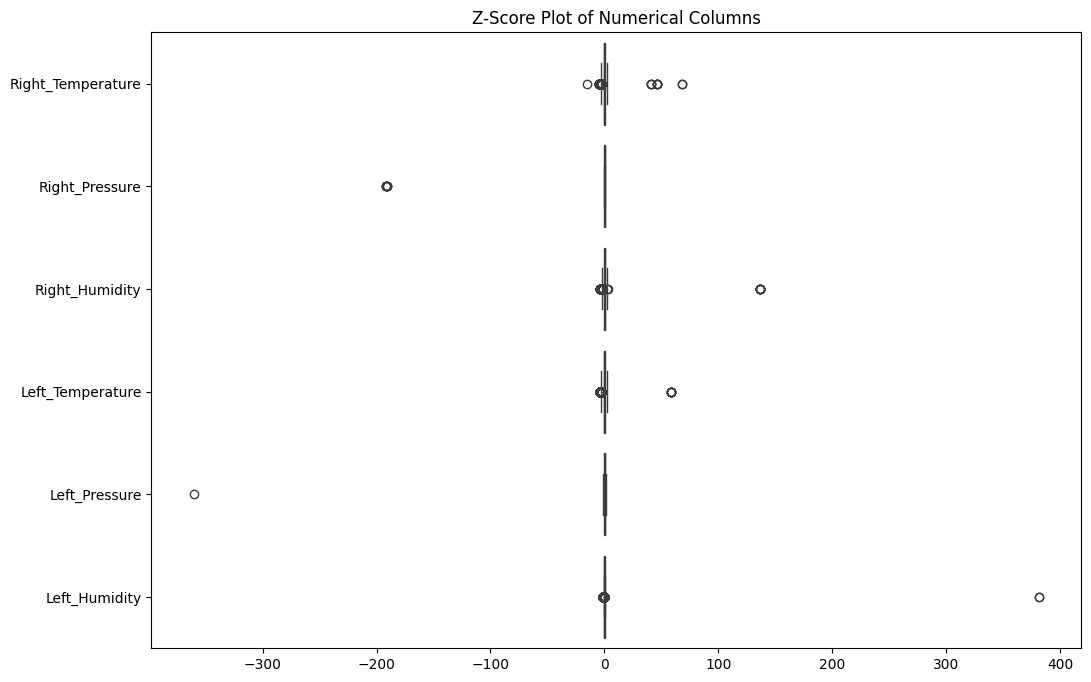

In [14]:
# Create a horizontal boxplot using Seaborn to visualize the distribution of z-scores
from scipy.stats import zscore

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
z_scores = zscore(data[numerical_columns])
sns.boxplot(data=z_scores, orient='h')
plt.title('Z-Score Plot of Numerical Columns')
plt.show()


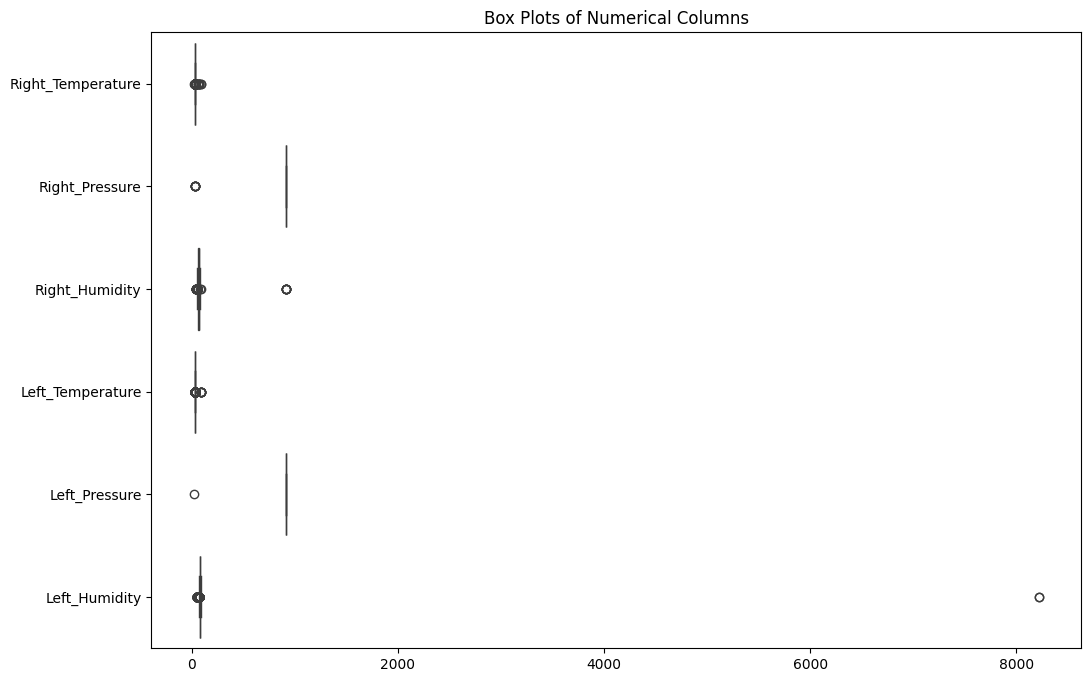

In [15]:
# Generate a horizontal boxplot using Seaborn to visualize the distribution of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

plt.figure(figsize=(12, 8))
sns.boxplot(data=data[numerical_columns], orient='h')
plt.title('Box Plots of Numerical Columns')
plt.show()


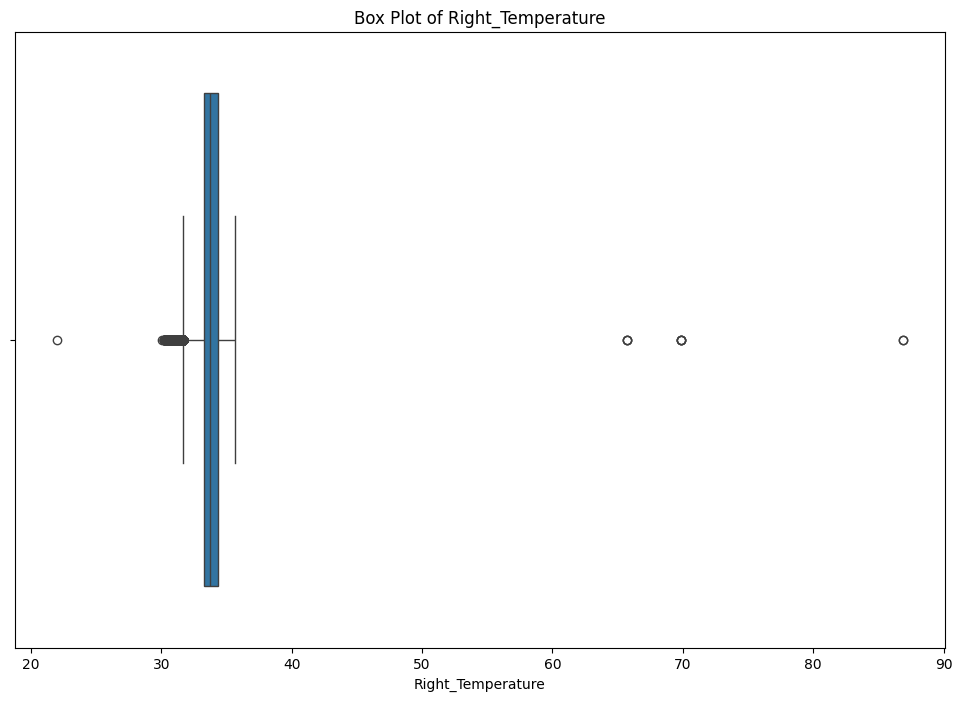

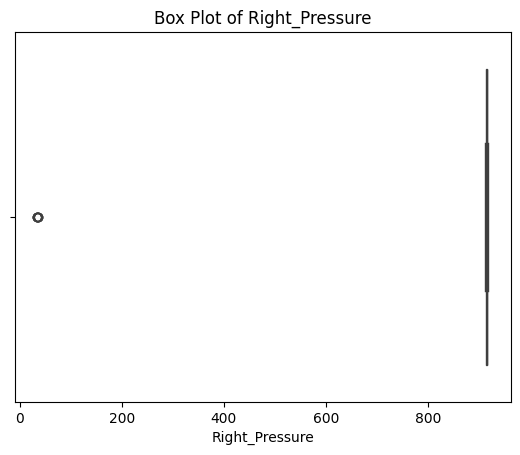

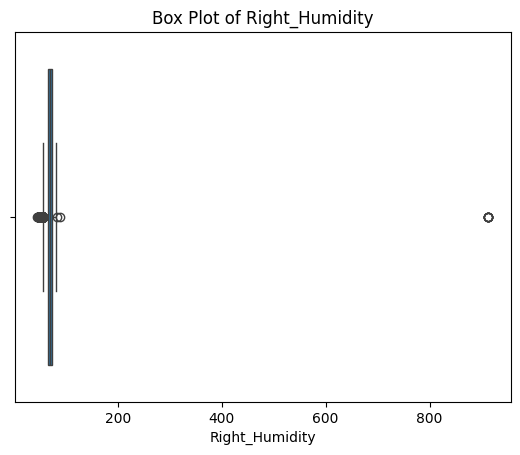

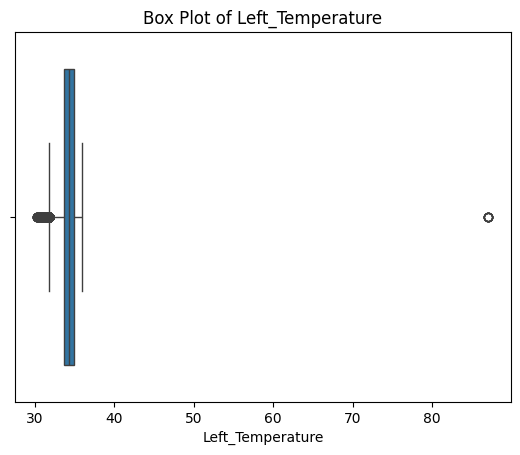

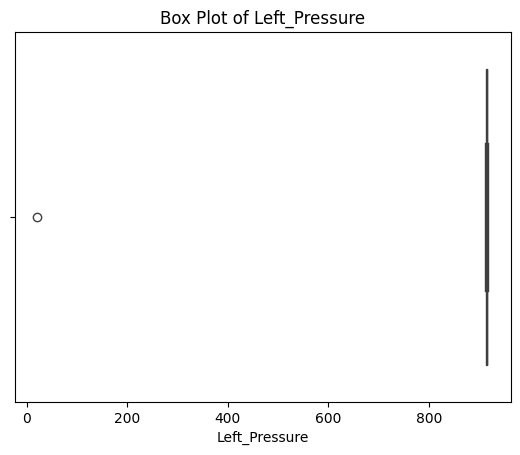

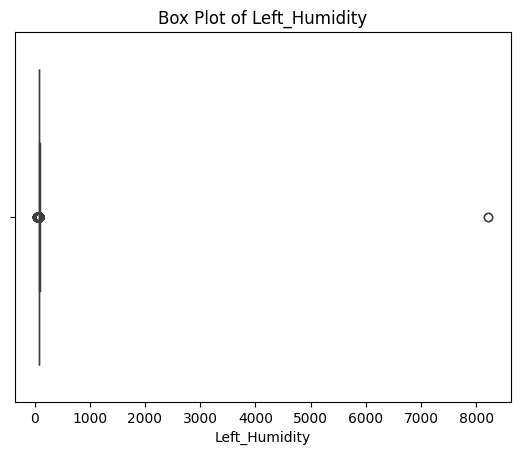

In [16]:
# Visualize box plots for numerical columns to identify outliers
numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
for column in numerical_columns:
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

In [17]:
# Remove outliers using the IQR method
iqr_multiplier = 1.5
for column in data.columns:
    if data[column].dtype in ['int64', 'float64']:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [18]:
# Display the first few rows of the dataset after removing outliers
data.head(11)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Dominant
0,33.13,911.9269,71.09,32.82,911.4244,89.27,L
1,33.06,911.9228,70.53,32.71,911.4431,89.17,L
2,33.00,911.9160,70.47,32.66,911.4019,89.33,L
3,32.96,911.9827,71.17,32.63,911.4224,89.54,L
4,32.95,911.9196,71.85,32.62,911.3900,89.75,L
5,32.96,911.9275,72.48,32.64,911.3817,89.93,L
6,32.99,911.9136,73.10,32.64,911.3817,89.93,L
7,33.05,911.9813,73.56,32.67,911.4032,90.20,L
8,33.12,911.9469,74.07,32.71,911.3582,90.20,L
9,33.12,911.9331,74.58,32.76,911.3544,90.36,L


In [19]:
# Display descriptive statistics of the cleaned dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity
count,292247.000000,292247.000000,292247.000000,292247.000000,292247.000000,292247.000000
mean,33.792699,914.794520,69.745061,34.274068,914.327754,83.395163
std,0.706685,1.827755,4.183779,0.828390,1.816732,4.118909
min,31.690000,911.752000,56.980000,31.900000,911.232100,72.210000
25%,33.330000,913.166800,66.860000,33.730000,912.760600,80.890000
50%,33.770000,915.347700,70.080000,34.260000,914.825400,83.740000
75%,34.370000,915.952600,72.880000,34.930000,915.457200,86.260000
max,35.660000,918.640800,81.000000,35.930000,918.200700,93.240000


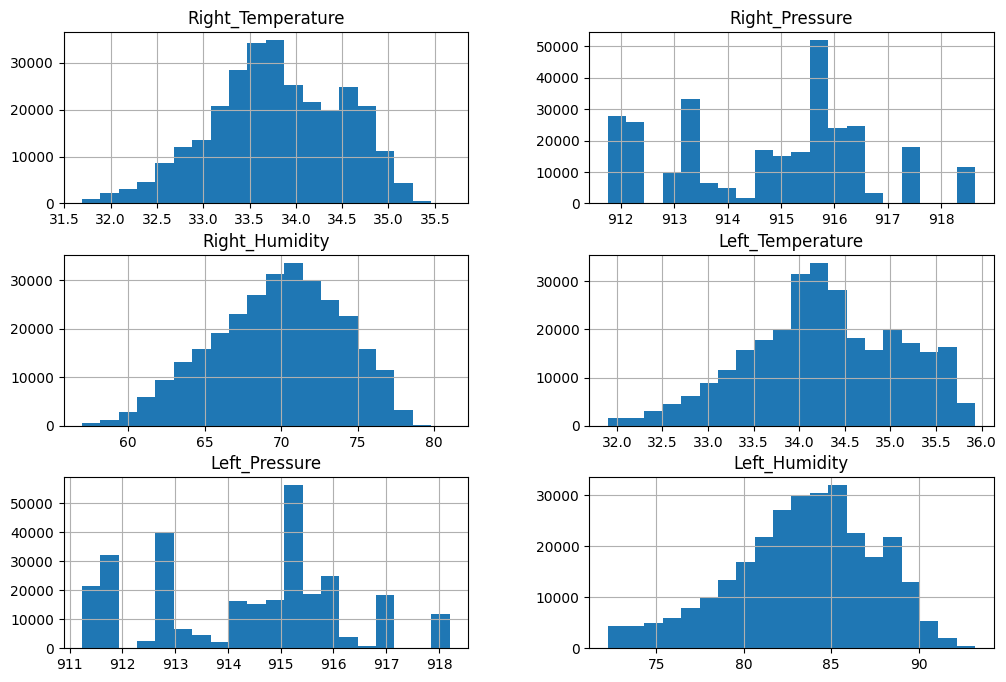

In [20]:
import matplotlib.pyplot as plt

# Visualize histograms for numerical columns
data.hist(bins=20, figsize=(12, 8))
plt.show()


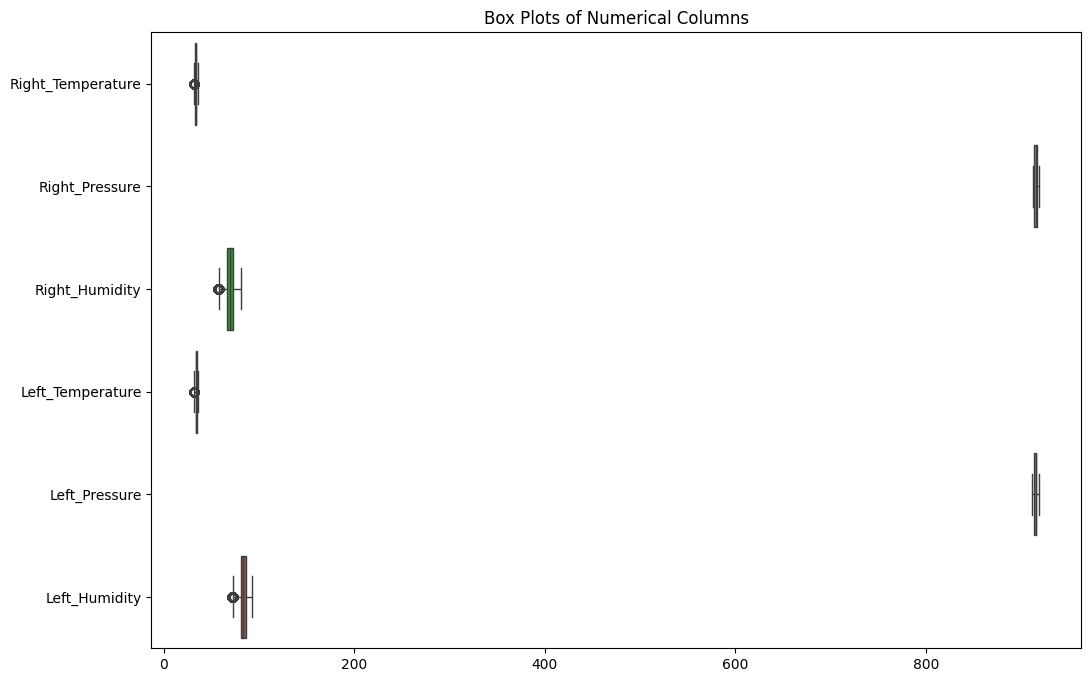

In [21]:
# Generate a horizontal boxplot using Seaborn to visualize the distribution of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

plt.figure(figsize=(12, 8))
sns.boxplot(data=data[numerical_columns], orient='h')
plt.title('Box Plots of Numerical Columns')
plt.show()


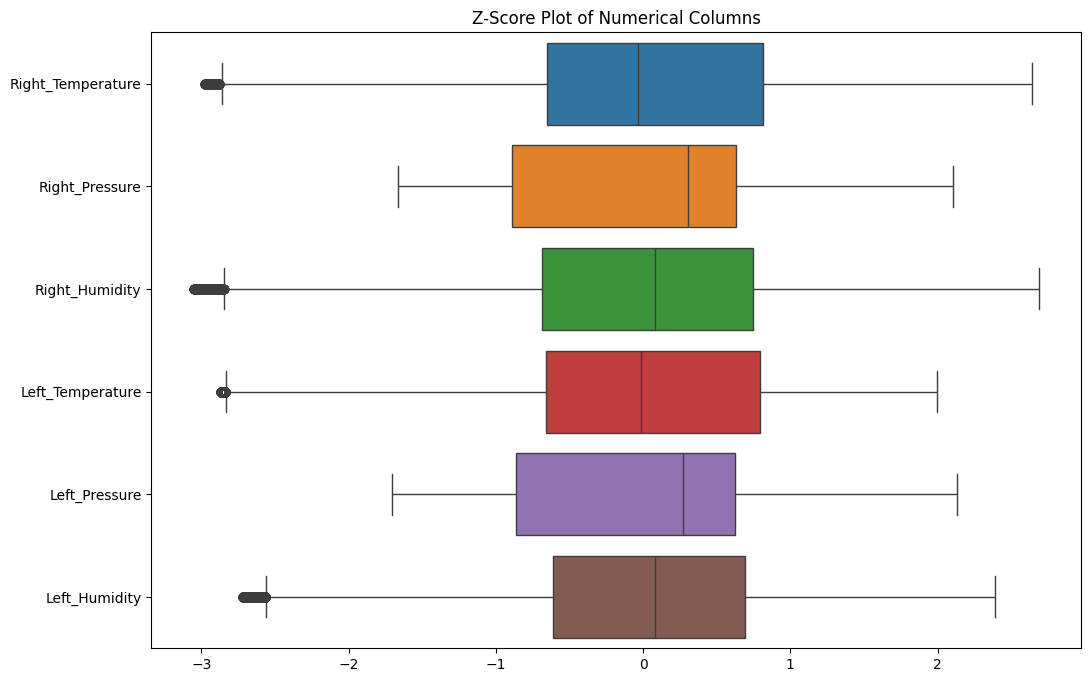

In [22]:
# Create a horizontal boxplot using Seaborn to visualize the distribution of z-scores
from scipy.stats import zscore

plt.figure(figsize=(12, 8))
z_scores = zscore(data[numerical_columns])
sns.boxplot(data=z_scores, orient='h')
plt.title('Z-Score Plot of Numerical Columns')
plt.show()


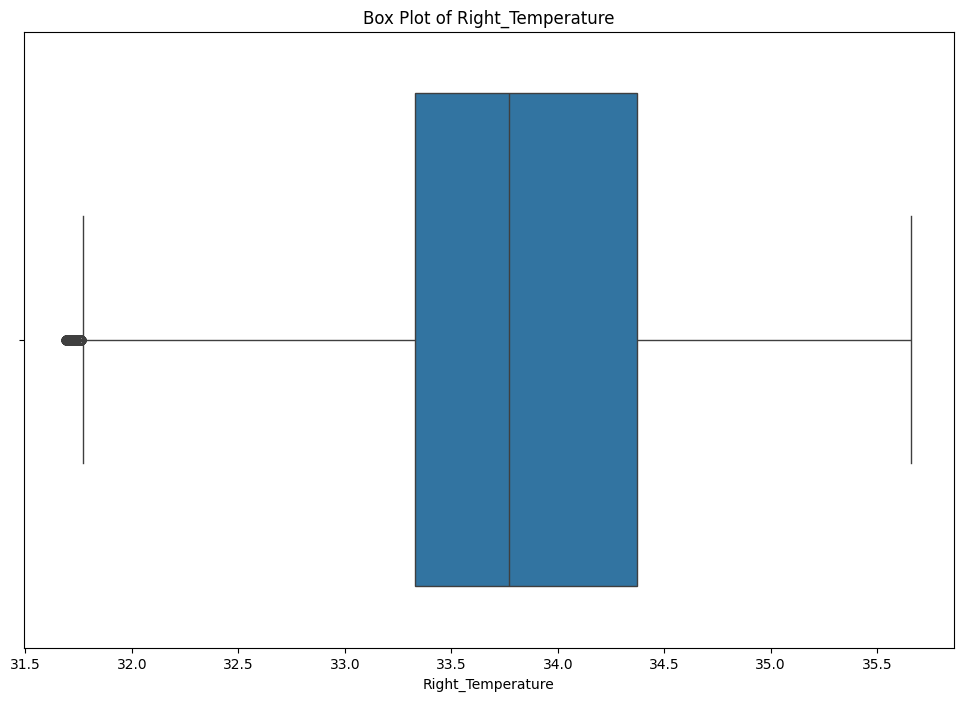

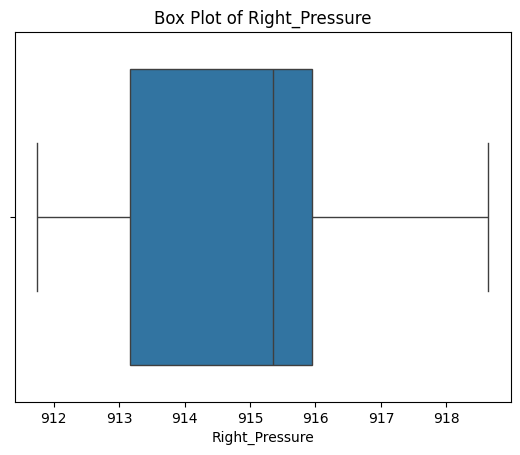

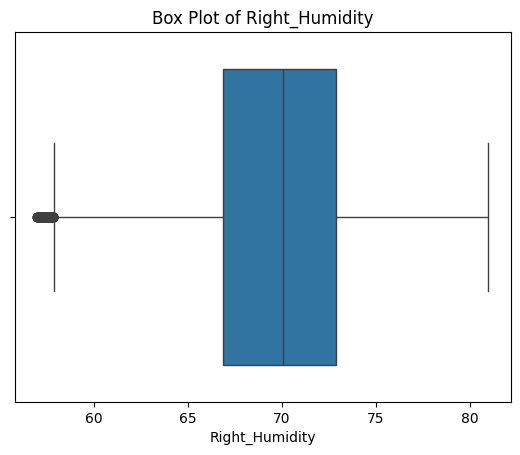

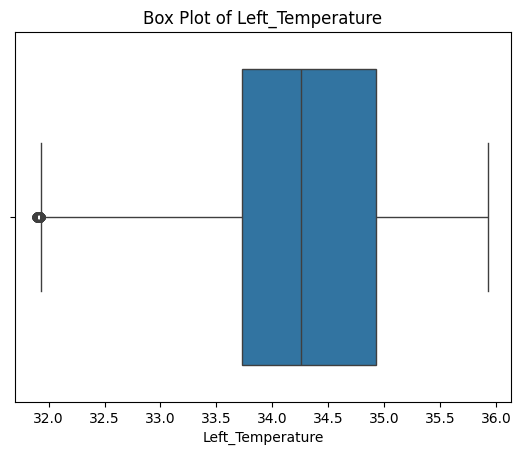

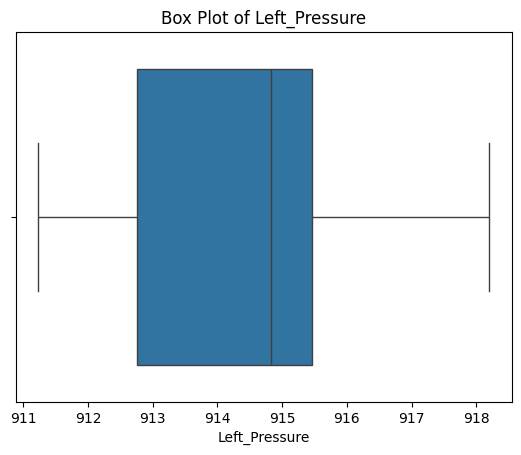

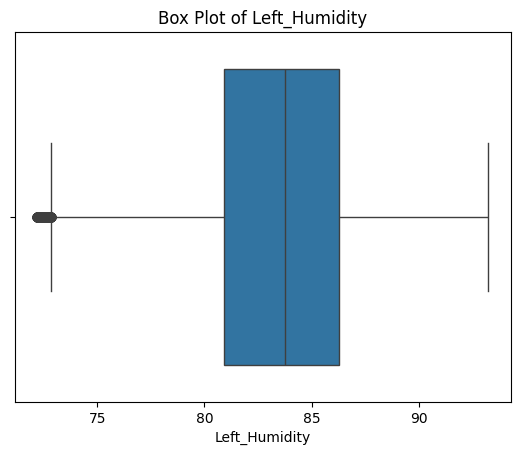

In [23]:
# Visualize box plots for numerical columns to chcek if the outliers are removed
numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
for column in numerical_columns:
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

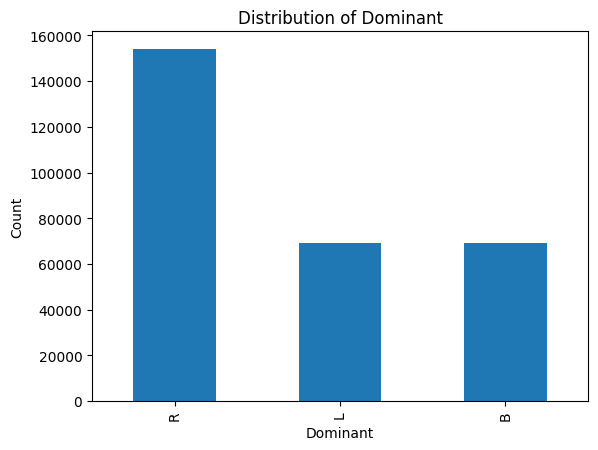

In [24]:
# Visualize the distribution of the 'Dominant' column
data['Dominant'].value_counts().plot(kind='bar')
plt.xlabel('Dominant')
plt.ylabel('Count')
plt.title('Distribution of Dominant')
plt.show()


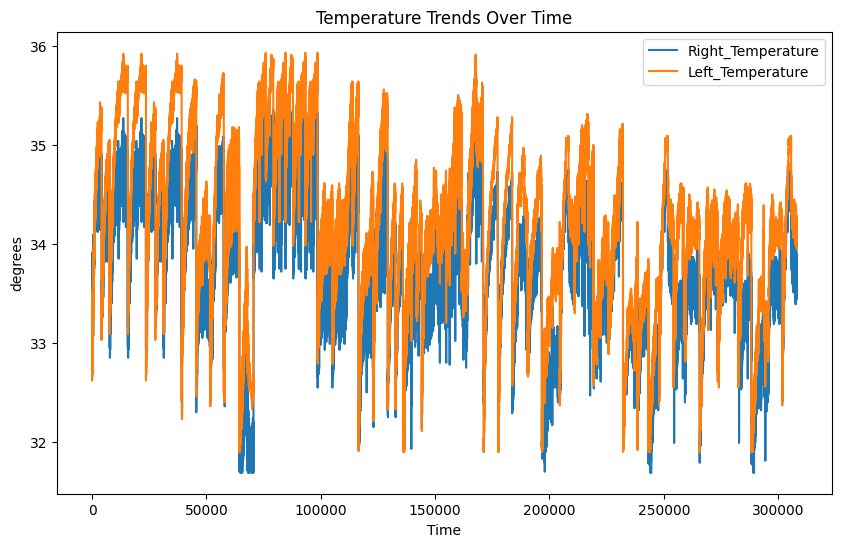

In [25]:
# Visualize temperature trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Temperature'], label='Right_Temperature')
plt.plot(data['Left_Temperature'], label='Left_Temperature')
plt.xlabel('Time')
plt.ylabel('degrees')
plt.title('Temperature Trends Over Time')
plt.legend()
plt.show()


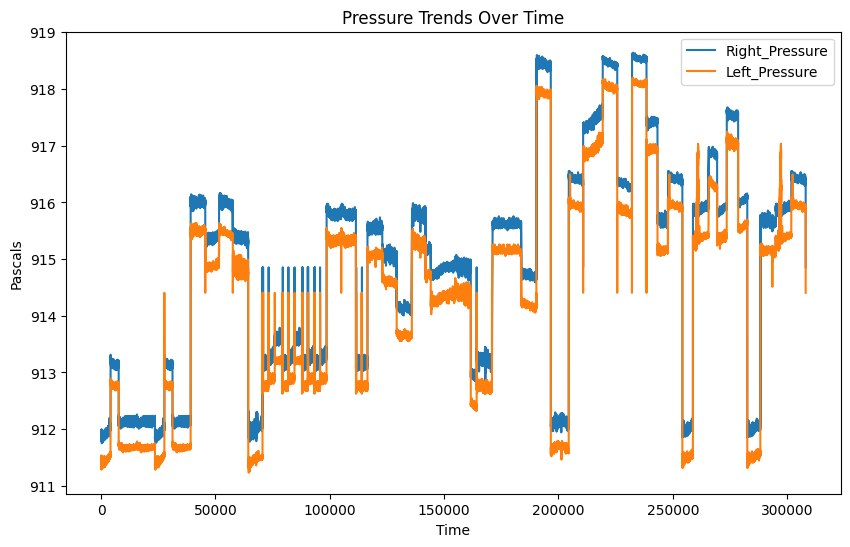

In [26]:
# Visualize pressure trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Pressure'], label='Right_Pressure')
plt.plot(data['Left_Pressure'], label='Left_Pressure')
plt.xlabel('Time')
plt.ylabel('Pascals')
plt.title('Pressure Trends Over Time')
plt.legend()
plt.show()

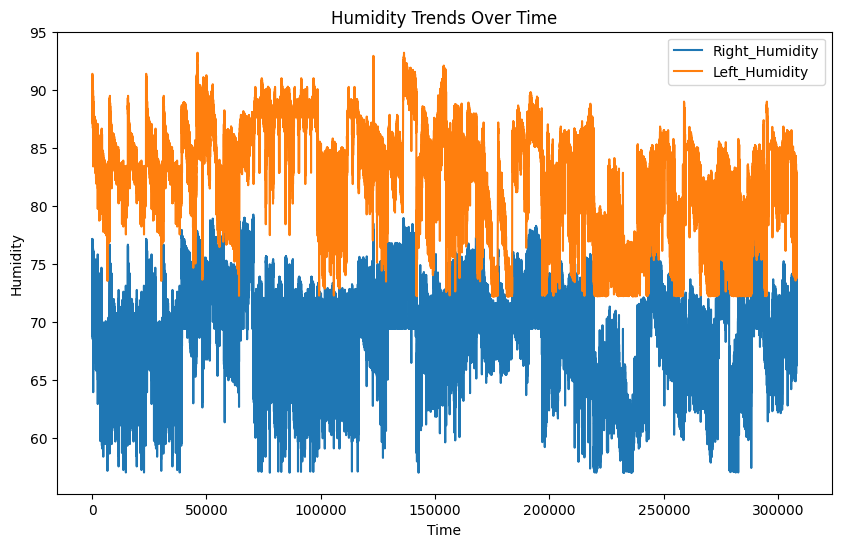

In [27]:
# Visualize humidity trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Humidity'], label='Right_Humidity')
plt.plot(data['Left_Humidity'], label='Left_Humidity')
plt.xlabel('Time')
plt.ylabel('Humidity')
plt.title('Humidity Trends Over Time')
plt.legend()
plt.show()

In [28]:
# to diaplay all the column names in the dataset
data.columns

Index(['Right_Temperature', 'Right_Pressure', 'Right_Humidity',
       'Left_Temperature', 'Left_Pressure', 'Left_Humidity', 'Dominant'],
      dtype='object')

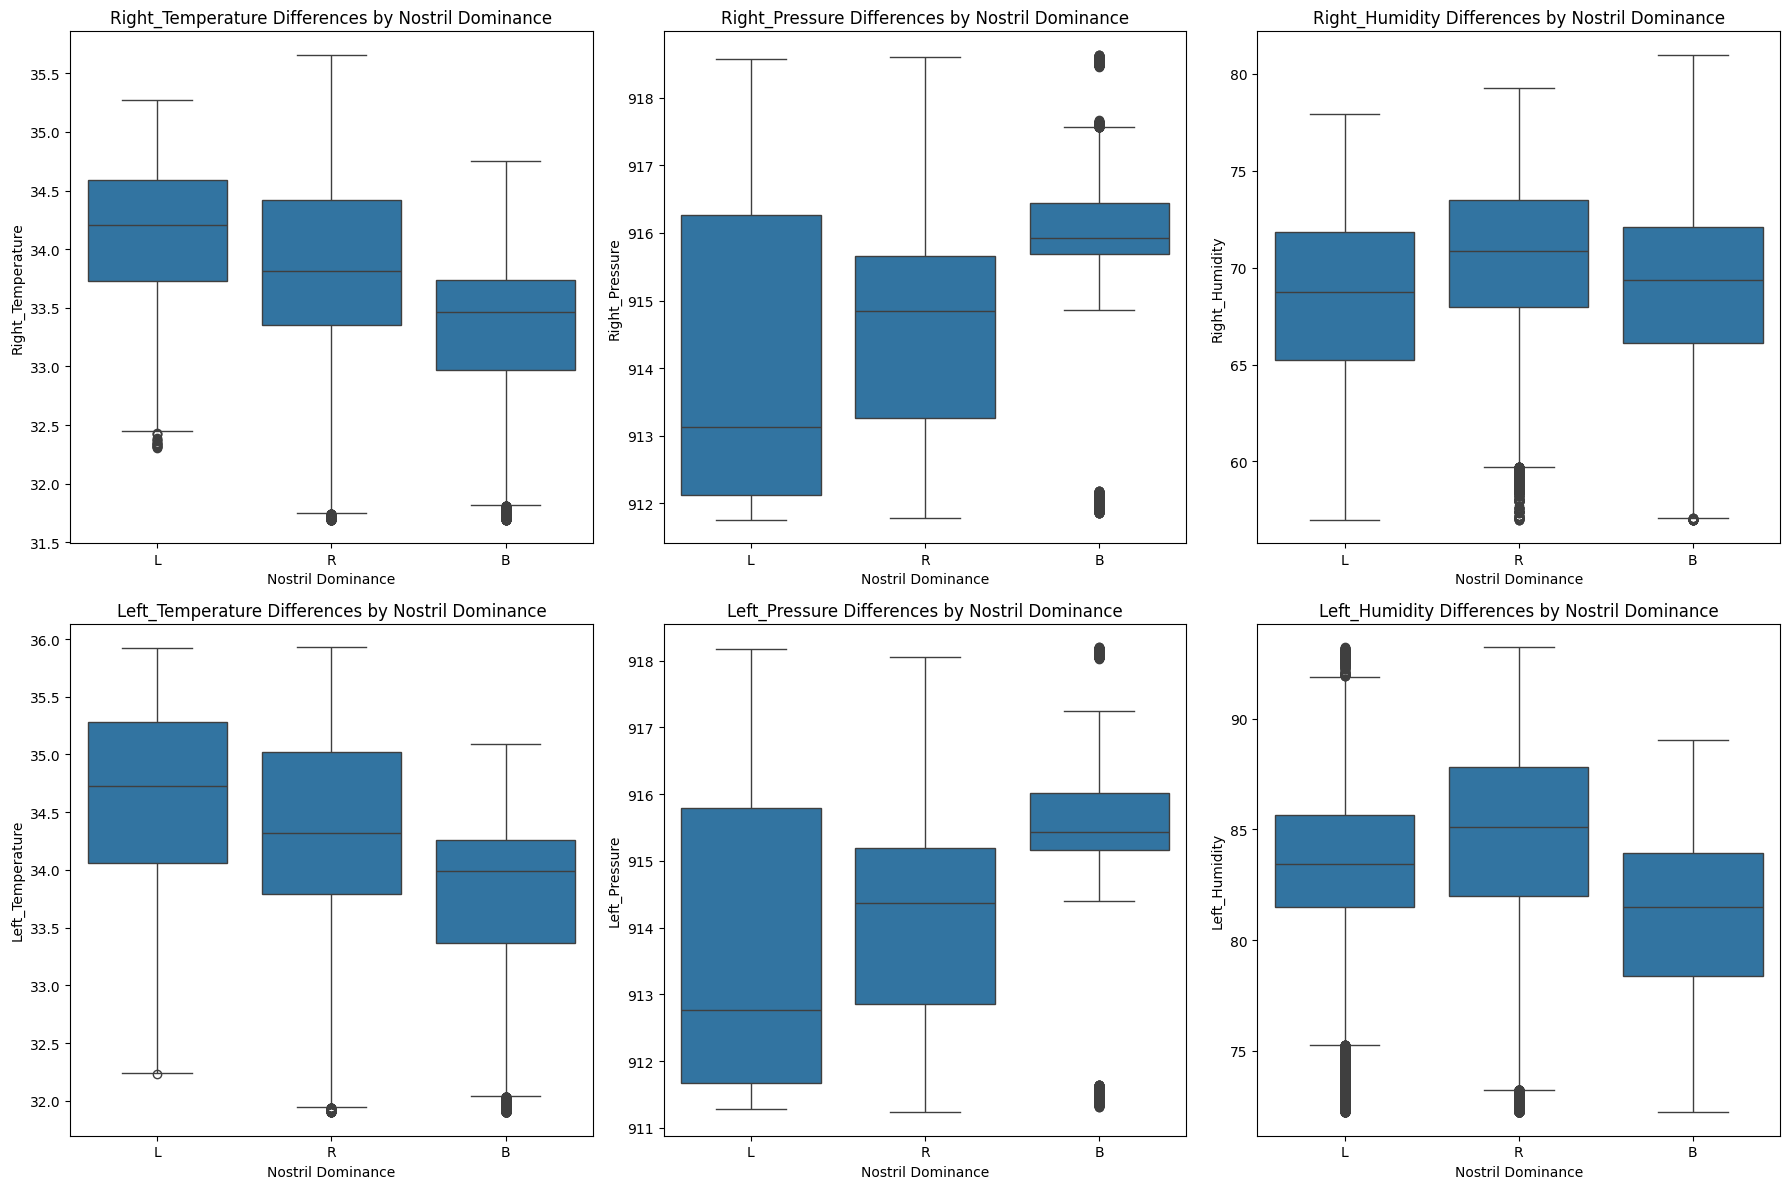

In [29]:
#Dataset understanding with Data Visualisation
# List of features to plot
features = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 
            'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

# Set up the plotting grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Loop through each feature and plot
for i, feature in enumerate(features):
    sns.boxplot(x='Dominant', y=feature, data=data, ax=axes[i])
    axes[i].set_title(f'{feature} Differences by Nostril Dominance')
    axes[i].set_xlabel('Nostril Dominance')
    axes[i].set_ylabel(feature)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [30]:
# Define features and target variable
features = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
target = ['Dominant']

In [31]:
# importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle

In [32]:
# Split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(data[features],data[target],test_size = 0.2, random_state = 101)

In [33]:
# Perform oversampling using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [34]:
# Ensure that the target variable is a 1D array
y_train_resampled = y_train_resampled.values.ravel()

In [35]:
# Shuffle the training data to avoid potential biases
X_train_resampled, y_train_resampled = shuffle(X_train_resampled, y_train_resampled, random_state=42)

In [36]:
# Use Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=10, random_state=42)

In [37]:
# Make predictions on the test set
predictions_rf = rf_model.predict(X_test)
predictions_rf

array(['B', 'L', 'R', ..., 'B', 'R', 'R'], dtype=object)

In [38]:
# Example input for prediction
input = [[33.13,911.9269,71.09,32.82,911.4244,89.27]]
# Make a prediction using the trained model
prediction = rf_model.predict(input)
print(prediction)

['L']


c:\Users\ompat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [39]:
# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, predictions_rf)
conf_matrix_rf = confusion_matrix(y_test, predictions_rf)
classification_report_rf = classification_report(y_test, predictions_rf)

In [40]:
# Displaying the evaluated values
print(f"Random Forest Accuracy: {accuracy_rf}")
print("Confusion Matrix:")
print(conf_matrix_rf)
print("Classification Report:")
print(classification_report_rf)

Random Forest Accuracy: 0.9586484174508126
Confusion Matrix:
[[12691     9   956]
 [   20 13691    14]
 [ 1350    68 29651]]
Classification Report:
              precision    recall  f1-score   support

           B       0.90      0.93      0.92     13656
           L       0.99      1.00      1.00     13725
           R       0.97      0.95      0.96     31069

    accuracy                           0.96     58450
   macro avg       0.96      0.96      0.96     58450
weighted avg       0.96      0.96      0.96     58450



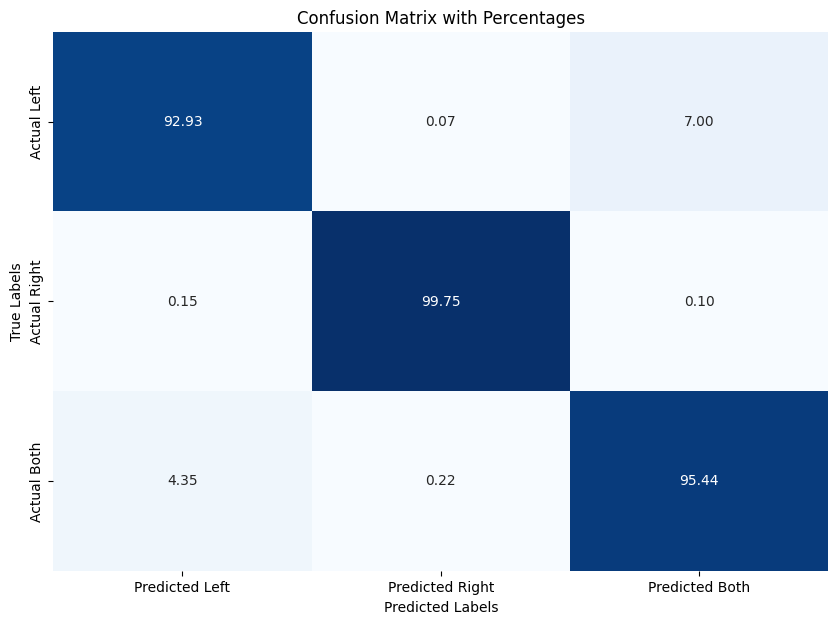

In [41]:
# Calculate confusion matrix percentages
conf_matrix_rf_percent = conf_matrix_rf / conf_matrix_rf.sum(axis=1)[:, np.newaxis] * 100

# Plot confusion matrix with annotations as percentages
plt.figure(figsize=(10, 7))
ax = sns.heatmap(conf_matrix_rf_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False, 
                 xticklabels=['Predicted Left', 'Predicted Right', 'Predicted Both'], 
                 yticklabels=['Actual Left', 'Actual Right', 'Actual Both'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix with Percentages')
plt.show()

In [42]:
# Accuracy of the model
accuracy = accuracy_score(y_test, predictions_rf)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9586484174508126


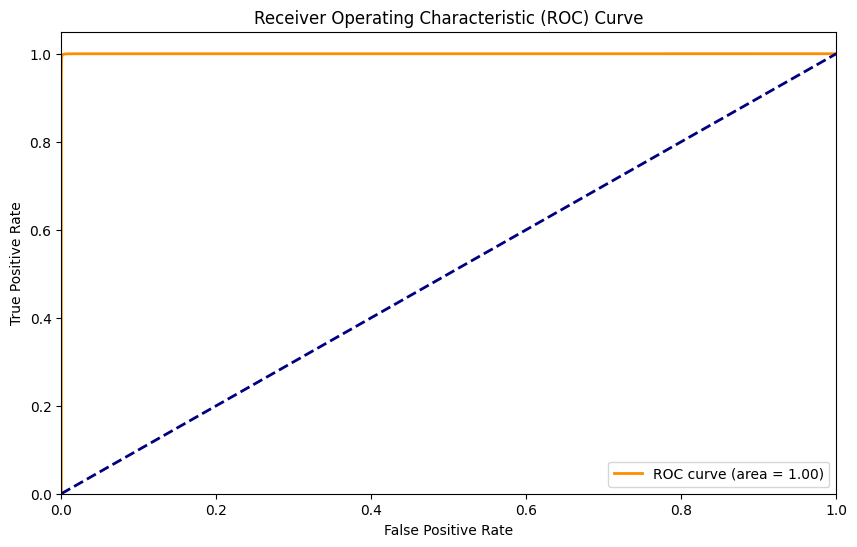

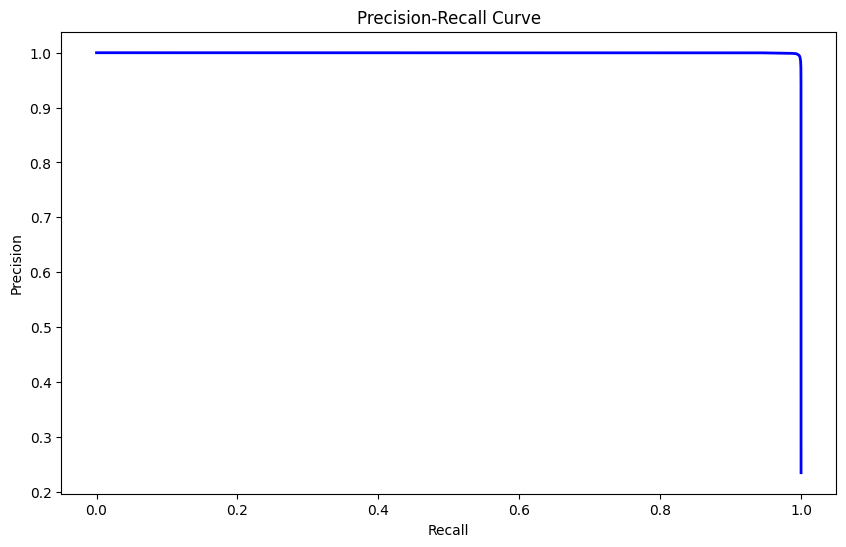

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calculate the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1], pos_label=rf_model.classes_[1])
roc_auc = auc(fpr, tpr)

# Calculate the Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:, 1], pos_label=rf_model.classes_[1])

# Plot the ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


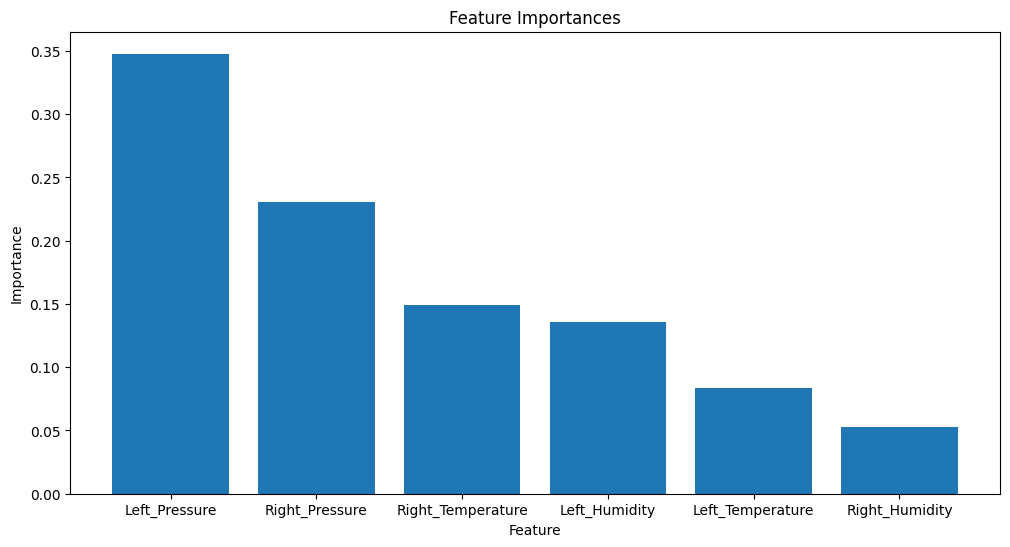

In [44]:
# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature Importances')
plt.bar(range(X_train_resampled.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_resampled.shape[1]), [features[i] for i in indices])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

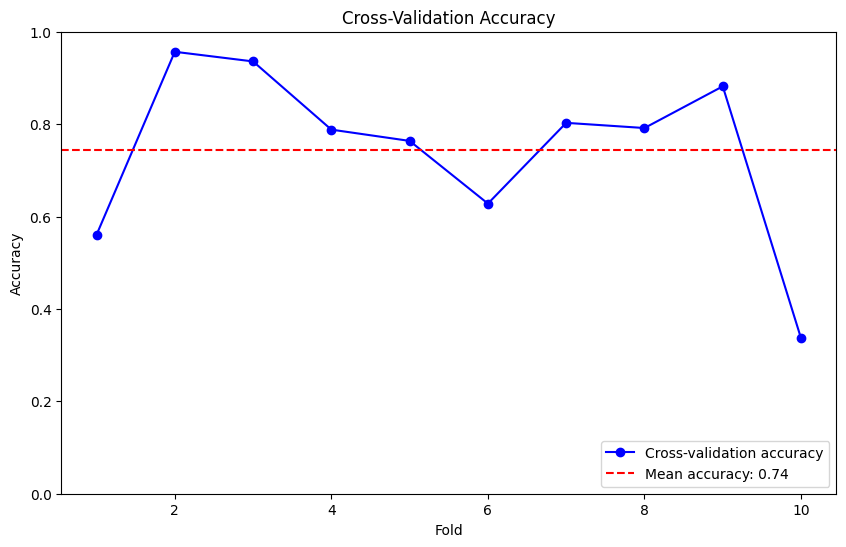

Cross-validation accuracies: [0.5602053  0.95657827 0.93570573 0.78809239 0.76366125 0.62795552
 0.8027716  0.7915412  0.88177525 0.33633315]
Mean cross-validation accuracy: 0.7444619662946212


In [45]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Perform 10-fold cross-validation
cv_scores = cross_val_score(rf_model, data[features], data['Dominant'], cv=10, scoring='accuracy')

# Plot the cross-validation accuracy scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='-', color='b', label='Cross-validation accuracy')
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean accuracy: {np.mean(cv_scores):.2f}')
plt.ylim([0, 1])
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

print(f'Cross-validation accuracies: {cv_scores}')
print(f'Mean cross-validation accuracy: {np.mean(cv_scores)}')


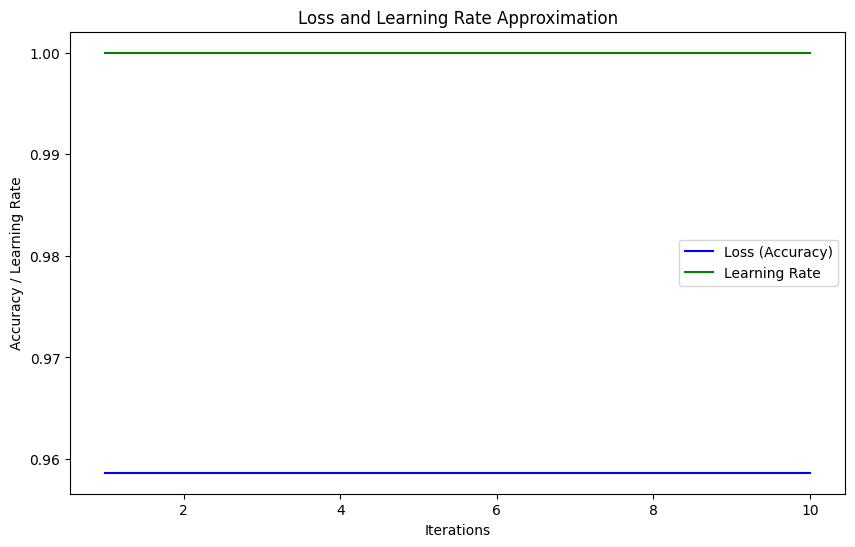

In [46]:
# Plot Loss, Learning Rate, and Epoch Curve (approximation for RandomForestClassifier)
# As RandomForestClassifier doesn't have these concepts directly, we can approximate them with iterations
iterations = range(1, len(rf_model.estimators_) + 1)
loss = [accuracy_rf] * len(iterations)  # Since RandomForestClassifier doesn't have a loss function
learning_rate = [1] * len(iterations)   # Constant learning rate for RandomForestClassifier
plt.figure(figsize=(10, 6))
plt.plot(iterations, loss, label='Loss (Accuracy)', color='blue')
plt.plot(iterations, learning_rate, label='Learning Rate', color='green')
plt.xlabel('Iterations')
plt.ylabel('Accuracy / Learning Rate')
plt.title('Loss and Learning Rate Approximation')
plt.legend()
plt.show()

In [47]:
prediction_proba = rf_model.predict_proba(input)
print(f"Prediction Probabilities: {prediction_proba}")

Prediction Probabilities: [[0. 1. 0.]]


c:\Users\ompat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [48]:
# Labeling the prediction probabilities
labels = rf_model.classes_
proba_percent = prediction_proba[0] * 100
proba_dict = {label: f"{prob:.2f}%" for label, prob in zip(labels, proba_percent)}

In [49]:
print(f"Prediction: {prediction[0]}")
print(f"Prediction Probabilities: {proba_dict}")

Prediction: L
Prediction Probabilities: {'B': '0.00%', 'L': '100.00%', 'R': '0.00%'}


In [50]:
# Save the trained model to a file
import pickle
pickle.dump(rf_model, open('model.pkl', 'wb'))
